## Student Exam Performance Analysis
Spring 2026 Data Science Project  
Cadence Cheng, Matthew Gu, Myungjun Ko, Luis Menjivar  

Contributions:
- Cadence Cheng: A, B, C, G (Contributed to project idea/choosing dataset, data preprocessing, correlation testing, and final tutorial references/review)
- Matthew Gu: A, B, C, G (Contributed to project idea/choosing dataset, data preprocessing, ANOVA test, insights and conclusions, general clarity edits, tutorial details, final HTML conversion and submission)
- Myungjun Ko : A, B, C, G (Contributed to the project idea/choosing dataset, data preprocessing, t-test, initial final tutorial creation)
- Luis Menjivar: A, B, D, E, F (Contributed to project idea/choosing dataset, data preprocessing, machine learning design/training, and visualization/insights)


## Table of Contents

1. Introduction
2. Data Curation
3. Exploratory Data Analysis
4. ML Algorithm Training and Test Data Analysis
5. Visualization
6. Insights and conclusions
7. References

## Introduction

Student academic performance is influenced by a variety of factors. It can be affected by study habits, the home and the school environment, individual behavior. In this tutorial, we employ the data science lifecycle towards identifying which of these factors has the greatest impact.

Why is this important? We believe that understanding these factors can help improve students’ learning outcomes, and it can also support better decision making for policymakers, such as those in legislative and educational institutions.

Our dataset used in this project includes information on over 6000 students. It contains both academic and lifestyle related variables such as study hours, attendance, participation in extracurricular activities, sleep duration, and the distance from home to school.

In our exploratory data analysis, we begin to investigate these factors by applying some preliminary statistical tests towards the following questions:
- Does the distance between home and school have a statistically significant effect on exam scores?
- Does participation in extracurricular activities influence academic performance?
- Is there a statistically significant relationship between attendance and exam scores?

Later, we apply machine learning techniques to conduct a more in depth analysis to identify the key factors that have a real impact on academic performance.

Through this analysis, we aim to model a data-driven process that can produce meaningful insights that can contribute to improving student achievement and enhancing our understanding of the educational environment.

## Data Curation

Chosen dataset: https://www.kaggle.com/datasets/grandmaster07/student-exam-performance-dataset-analysis

In this section, we use pandas to load, organize, and preprocess the dataset for analysis. The dataset used in this project was obtained from Kaggle. This public domain dataset with over 6000 data points is a convenient, readily accessible choice for the educational purpose of this tutorial.

We first import the necessary Python libraries for the initial data processing and exploratory analysis, which you can find listed blow. Then, we load the dataset using Kaggle and import it into a pandas DataFrame for analysis.

In [ ]:
import kagglehub
import pandas as pd
import numpy as np

from scipy.stats import f_oneway, tukey_hsd, ttest_ind, pearsonr

import matplotlib.pyplot as plt
import seaborn as sns


path = kagglehub.dataset_download("grandmaster07/student-exam-performance-dataset-analysis")

df = pd.read_csv("/kaggle/input/student-exam-performance-dataset-analysis/StudentPerformanceFactors.csv")


Using Colab cache for faster access to the 'student-exam-performance-dataset-analysis' dataset.


After loading the dataset, we examine the structure and data types of each column.

In [ ]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [ ]:
df.dtypes
df.count()

,0
Hours_Studied,6607
Attendance,6607
Parental_Involvement,6607
Access_to_Resources,6607
Extracurricular_Activities,6607
Sleep_Hours,6607
Previous_Scores,6607
Motivation_Level,6607
Internet_Access,6607
Tutoring_Sessions,6607


We then check for missing values and remove them to ensure consistency in our analysis.

In [ ]:
df = df.dropna()
df.count()

,0
Hours_Studied,6378
Attendance,6378
Parental_Involvement,6378
Access_to_Resources,6378
Extracurricular_Activities,6378
Sleep_Hours,6378
Previous_Scores,6378
Motivation_Level,6378
Internet_Access,6378
Tutoring_Sessions,6378


We examined the number each column, and we found a total of 6,607 entries. However, some columns such as Teacher Quality, Parental Education Level, and Distance from Home had fewer observations, indicating the presence of missing values. We removed rows containing missing values using the dropna() function to ensure our data consistency. After this step, we acquired 6,378 clean dataset suitable for further analysis.

## Exploratory data analysis

### ANOVA Test

We examine whether the distance from home has a statistically significant effect on exam scores. To do this, we perform ANOVA test by grouping students based on their distance from home.

First, we're going to group the original dataframe by distance from home in order to test if differences in that variable are signicant in regard to students' exam scores.

In [ ]:
# Grouping the dataframe by different distances from home, and splitting it accordingly
distances_dfs = dict(tuple(df.groupby(df['Distance_from_Home'])))

There are three possible values for the 'Distance_from_Home' variable: Far, Moderate, and Near.

Now that we've grouped the data by these values, we can run an ANOVA test on these groups for their means of the Exam_Score variable, to see if there is a statistically significant difference between these groups. Our null hypothesis that there is no difference; our alternate hypothesis is that there is at least one.

In [ ]:
# run ANOVA
results = f_oneway(distances_dfs['Far']['Exam_Score'], distances_dfs['Moderate']['Exam_Score'], distances_dfs['Near']['Exam_Score'])
# print result
results.pvalue

np.float64(1.6303083634793744e-11)

We get a value of '1.4705413873700491e-12', which is significantly under the classic alpha value of 0.05 and provides enough statistical evidence to reject our null hypothesis - there is a significant difference somewhere between these three groups!

Now, we're going to use the Tukey HSD post-hoc test to narrow down which groups are actually statistically different.

In [ ]:
# run + print tukey hsd
results = tukey_hsd(distances_dfs['Far']['Exam_Score'], distances_dfs['Moderate']['Exam_Score'], distances_dfs['Near']['Exam_Score'])
print(results)

Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)     -0.488     0.017    -0.906    -0.071
 (0 - 2)     -1.015     0.000    -1.407    -0.624
 (1 - 0)      0.488     0.017     0.071     0.906
 (1 - 2)     -0.527     0.000    -0.782    -0.272
 (2 - 0)      1.015     0.000     0.624     1.407
 (2 - 1)      0.527     0.000     0.272     0.782



It looks like, based on the p-values and our alpha value of 0.05, all of the differences between the three groups are statistically significant - although there's slightly weaker evidence for the difference between the far and moderate groups. This indicates that there is compelling evidence that exam scores are different across groups of students categorized by their distance from home.

Finally, we'll create a graph mapping their distributions to see the differences in exam score visually.

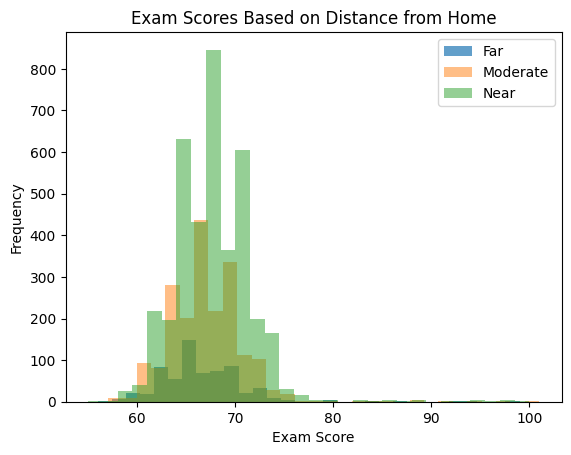

In [ ]:
plt.hist(distances_dfs['Far']['Exam_Score'], bins=30, alpha=0.7)
plt.hist(distances_dfs['Moderate']['Exam_Score'], bins=30, alpha=0.5)
plt.hist(distances_dfs['Near']['Exam_Score'], bins=30, alpha=0.5)
plt.legend(['Far', 'Moderate', 'Near'])
plt.title("Exam Scores Based on Distance from Home")
plt.ylabel("Frequency")
plt.xlabel("Exam Score")
plt.show()

The graph visibly confirms the results of these statistical tests, with the distribution of students near home being the most clearly skewed right (suggesting unusually higher scores).

### T-test

Next, we analyze whether participation in extracurricular activities affects exam performance by comparing students who participate in extracurricular activities with those who do not using T-test.

In [ ]:
df["Extracurricular_Activities"].value_counts()

,count
Extracurricular_Activities,
Yes,3807
No,2571


In [ ]:
df.groupby("Extracurricular_Activities")["Exam_Score"].agg(["count", "mean", "median", "std"])

,count,mean,median,std
Extracurricular_Activities,,,,
No,2571,66.951770,67.0,3.807325
Yes,3807,67.454951,67.0,3.972449


We calculate summary statistics for each group, including the number of students, mean, median and the standard deviation of exam scores.

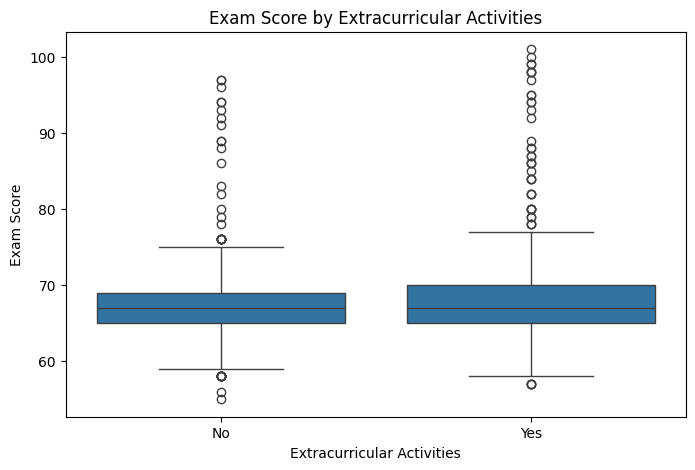

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Extracurricular_Activities", y="Exam_Score")
plt.title("Exam Score by Extracurricular Activities")
plt.xlabel("Extracurricular Activities")
plt.ylabel("Exam Score")
plt.show()

The boxplot shows the distribution of exam scores for students who participate in extra curricular activities and those who do not.

In [ ]:
yes_scores = df[df["Extracurricular_Activities"] == "Yes"]["Exam_Score"]
no_scores = df[df["Extracurricular_Activities"] == "No"]["Exam_Score"]

To perform the t-test, we separate the exam scores into two groups. Students who participate in extracurricular activities and students who do not.

In [ ]:
t_stat, p_value = ttest_ind(yes_scores, no_scores, equal_var=False)

print("t-statistic:", t_stat)
print("p-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("Conclusion: Reject H0. The average exam scores are significantly different.")
else:
    print("Conclusion: Fail to reject H0. The average exam scores are not significantly different.")

t-statistic: 5.0872502640494215
p-value: 3.749899967542053e-07
Conclusion: Reject H0. The average exam scores are significantly different.


We used an independent two-sample t-test to compare exam scores between students who participate in extracurricular activities and those who do not. The test produced a t-statistic of 5.09 and a p-value is far below 0.05. Therefore, we rejected the null hypothesis and concluded that there is a statistically significant difference in exam scores between the two groups. Students who participated in extracurricular activities had a slightly higher average exam score (67.45) than students who did not (66.95).

### Correlation Testing

Finally, we examine the relationship between attendance and exam scores using correlation analysis.

In [ ]:
corr, p_value = pearsonr(df['Attendance'], df['Exam_Score'])

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: 0.5802585402382587
P-value: 0.0


There appears to be a moderate, positive correlation between Attendance and Exam Score. This statistic is significant according to the p-value being below 0.05.

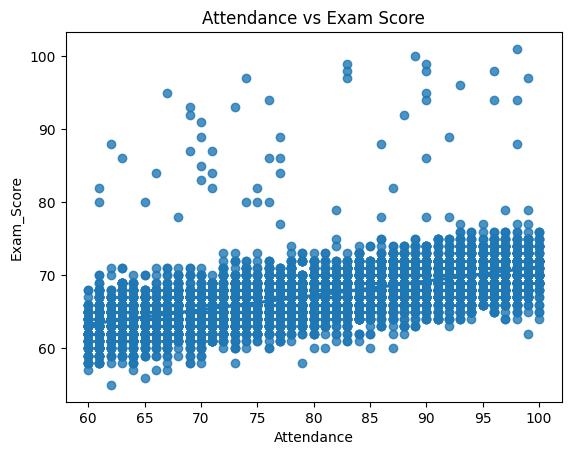

In [ ]:
sns.regplot(x='Attendance', y='Exam_Score', data=df)
plt.title("Attendance vs Exam Score")
plt.show()

We conducted a Pearson correlation test in order to see if there is a relationship between Attendance and Exam Score. According to the test, there is a statistically significant, moderate, positive correlation, indicating that higher attendance is associated with higher exam scores. However, as illustrated in the graph, the relationship is not strong. The data is a little spread out and there are high scorers among those of almost all levels of attendance, indicating that attendance is not the only factor that contributes to exam scores.

## Primary analysis

The goal of this section is to predict a student's Exam_Score using the other student performance factors in the dataset. Since Exam_Score is a numeric value, this is a regression problem. It's also not a classification problem because we are not trying to place students into fixed categories.

Instead, we are trying to estimate a score based on study habits, school support, family background, and personal factors. To design the machine learning approach, we split the dataset into features and a target variable.

The target variable is Exam_Score, while all other columns are used as possible predictors. The dataset has both numeric variables, such as Hours_Studied, Attendance, and Previous_Scores, and categorical variables, such as Parental_Involvement, Access_to_Resources, and Distance_from_Home. Because machine learning models need numeric input, the categorical columns are converted with one-hot encoding. Numeric columns are scaled so that large-number features do not have too much influence only because of their size.

I tested several regression models so the project would not depend on only one method. The baseline mean model gives a simple starting point by predicting the average exam score for every student.

Linear Regression and Ridge Regression are useful because they are easy to understand and show whether the predictors have a mostly linear relationship with exam scores. Random Forest and Gradient Boosting are also tested because they can capture more complex patterns in the data.

Some especially helpful references for the modeling tools used here include the scikit-learn documentation for pipelines and preprocessing, which you can find here:
- https://scikit-learn.org/stable/modules/compose.html
- https://scikit-learn.org/stable/modules/preprocessing.html.

To distinguish this from the other sections, we import the libraries needed for our machine learning analysis below. You can find further resources on these in the References section.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# create a copy of the cleaned dataset for machine learning.
df_ml = df.copy()

# separate the prediction target from the input features.
target_column = "Exam_Score"
X = df_ml.drop(columns=[target_column])
y = df_ml[target_column]

# identify numeric and categorical columns.
numeric_columns = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_columns = X.select_dtypes(include=["object"]).columns.tolist()

print("Target variable:", target_column)
print("Number of input features before encoding:", X.shape[1])
print("Numeric columns:", numeric_columns)
print("Categorical columns:", categorical_columns)

Target variable: Exam_Score
Number of input features before encoding: 19
Numeric columns: ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']
Categorical columns: ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']


In [ ]:
# build preprocessing steps for numeric and categorical columns.
def build_preprocessor():
    numeric_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer(transformers=[
        ("num", numeric_pipeline, numeric_columns),
        ("cat", categorical_pipeline, categorical_columns)
    ])

    return preprocessor

# split the data so the model is tested on data it did not train on.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 5102
Testing rows: 1276


## ML Algorithm Training and Test Data Analysis

After designing the model pipeline, the next step is to train each model and compare the results. The training set is used to teach the model the relationship between student factors and exam scores. The test set is kept separate so we can check how well the model performs on new data.

The main metrics used are RMSE, MAE, and R². RMSE stands for root mean squared error. It shows the typical size of prediction errors, and larger errors are punished more. MAE stands for mean absolute error. It shows the average size of the prediction error in exam score points. R² shows how much of the variation in exam scores the model can explain. A higher R² is better, while lower RMSE and MAE values are better.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

# define the models that will be compared.
models = {
    "Baseline Mean Model": DummyRegressor(strategy="mean"),
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results = []
fitted_models = {}

for model_name, model in models.items():
    # the baseline model only predicts the mean, so it does not need preprocessing.
    if model_name == "Baseline Mean Model":
        pipeline = Pipeline(steps=[("model", model)])
    else:
        pipeline = Pipeline(steps=[
            ("preprocessor", build_preprocessor()),
            ("model", model)
        ])

    pipeline.fit(X_train, y_train)

    train_predictions = pipeline.predict(X_train)
    test_predictions = pipeline.predict(X_test)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_predictions))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))
    test_mae = mean_absolute_error(y_test, test_predictions)
    test_r2 = r2_score(y_test, test_predictions)

    results.append({
        "Model": model_name,
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse,
        "Test MAE": test_mae,
        "Test R2": test_r2
    })

    fitted_models[model_name] = pipeline

results_df = pd.DataFrame(results).sort_values("Test RMSE")
results_df

,Model,Train RMSE,Test RMSE,Test MAE,Test R2
2,Ridge Regression,2.071799,2.042833,0.487309,0.731445
1,Linear Regression,2.071799,2.042856,0.487287,0.731439
4,Gradient Boosting,1.968339,2.153423,0.824099,0.701581
3,Random Forest,0.870314,2.378446,1.129565,0.635955
0,Baseline Mean Model,3.906839,3.942067,2.908199,-0.000036


Based on the test results, Ridge Regression performed best in this run. It had the lowest test RMSE and a strong R² score compared with the other models. The baseline mean model performed much worse, which shows that the student factors in the dataset do help explain exam scores.

The Random Forest model had a much lower training error than testing error. This means it learned the training data very closely, but it did not generalize as well to new students. That is a sign of overfitting. Ridge Regression worked better because it kept the model simpler while still using the useful patterns in the dataset.

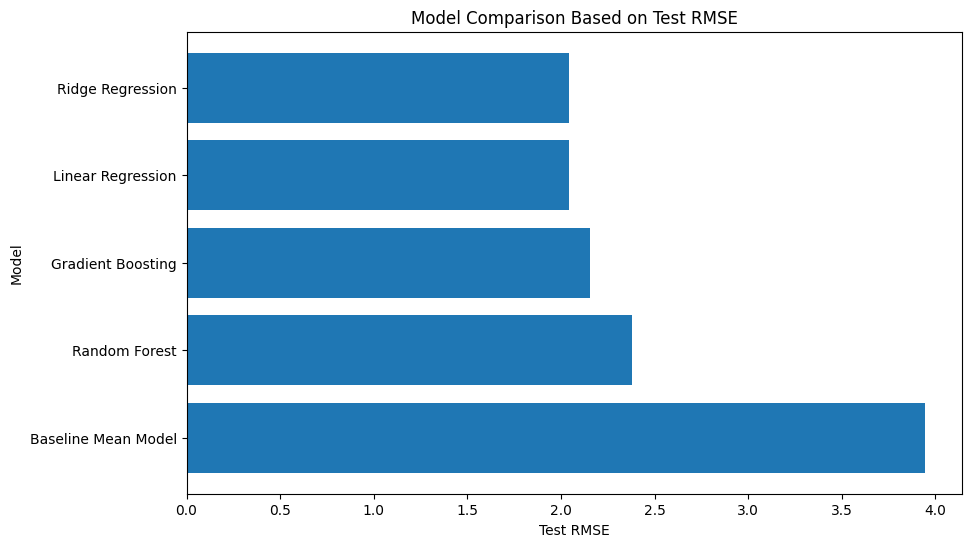

In [ ]:
# visualize the model comparison using Test RMSE.
sorted_results = results_df.sort_values("Test RMSE", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(sorted_results["Model"], sorted_results["Test RMSE"])
plt.title("Model Comparison Based on Test RMSE")
plt.xlabel("Test RMSE")
plt.ylabel("Model")
plt.gca().invert_yaxis()
plt.show()


In [ ]:
# save the best model based on the lowest Test RMSE.
best_model_name = results_df.iloc[0]["Model"]
best_model = fitted_models[best_model_name]

print("Best model:", best_model_name)

best_predictions = best_model.predict(X_test)

prediction_results = pd.DataFrame({
    "Actual Exam Score": y_test.values,
    "Predicted Exam Score": best_predictions
})

prediction_results.head(10)

Best model: Ridge Regression


,Actual Exam Score,Predicted Exam Score
0,74,73.970389
1,66,66.004791
2,70,70.470880
3,72,71.962731
4,67,67.459391
5,69,69.502691
6,72,72.267500
7,66,66.231697
8,69,68.844717
9,68,67.945576


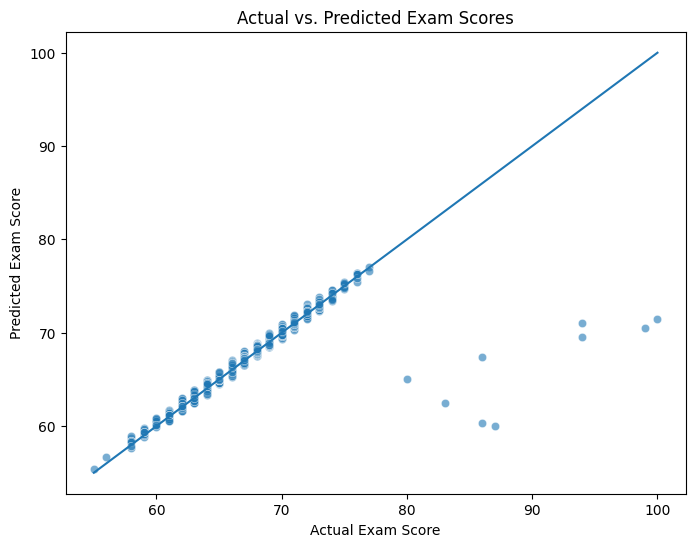

In [ ]:
# plot actual scores against predicted scores for the best model.
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=best_predictions, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.title("Actual vs. Predicted Exam Scores")
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.show()

In [ ]:
# use permutation importance to see which original features mattered most.
# this method checks how much model performance drops when each feature is shuffled.
importance_result = permutation_importance(
    best_model,
    X_test,
    y_test,
    scoring="r2",
    n_repeats=10,
    random_state=42
)

feature_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": importance_result.importances_mean
}).sort_values("Importance", ascending=False)

top_features = feature_importance.head(10)
top_features

,Feature,Importance
1,Attendance,0.671440
0,Hours_Studied,0.392589
6,Previous_Scores,0.063656
3,Access_to_Resources,0.061575
2,Parental_Involvement,0.060314
9,Tutoring_Sessions,0.053300
13,Peer_Influence,0.020051
16,Parental_Education_Level,0.018432
7,Motivation_Level,0.017651
10,Family_Income,0.016246


The machine learning results extend the earlier exploratory analysis and address some of its major unanswered questions. Attendance (which was one subject of EDA), hours studied, and previous scores were among the strongest predictors of exam performance. This makes sense because students who attend class more often and spend more time studying are more likely to perform better on exams. Access to resources and parental involvement also mattered, which suggests that school and home support can play a role in student outcomes.  
  
Ridge Regression was the best model because it balanced accuracy and generalization. It performed much better than the baseline model and avoided the stronger overfitting shown by Random Forest. The actual vs. predicted plot shows that many predictions are close to the true exam scores, but the model still makes mistakes for some students. This means exam performance is not explained by one factor alone. It is shaped by a mix of study behavior, past performance, support systems, and school-related conditions.

## Visualization

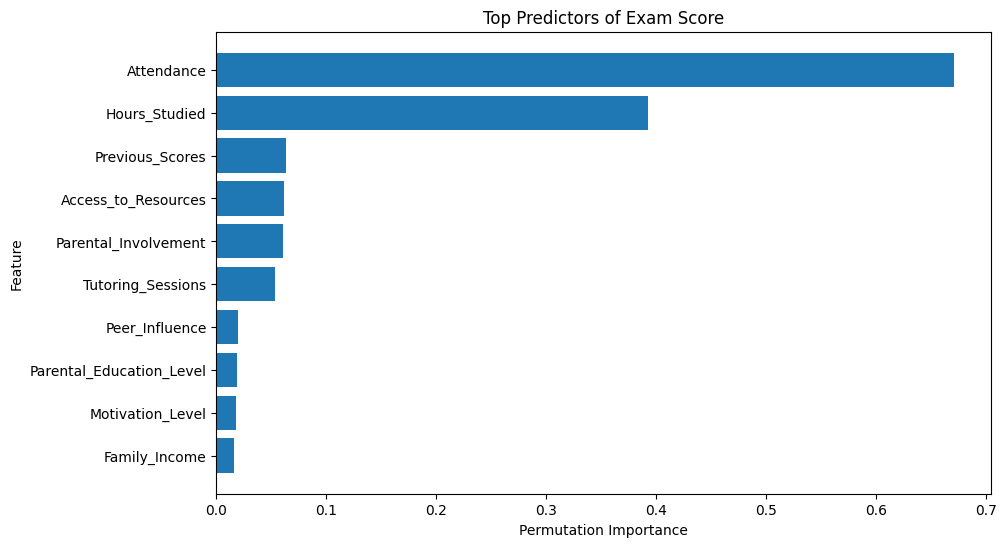

In [ ]:
# visualize the most important features for the best model.
top_features_sorted = top_features.sort_values("Importance", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(top_features_sorted["Feature"], top_features_sorted["Importance"])
plt.title("Top Predictors of Exam Score")
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.show()


## Insights and Conclusions

Overall, the model helps answer the main project question by showing which factors are most useful for predicting exam scores. The results suggest that attendance and study time are the strongest signals, but outside support factors should not be ignored. This aligns with broad existing understandings of how students can succeed in exam scores.

More broadly, this tutorial provides a useful model on how similar data analysis can be done on more local data. Analysts and consultants involved in other educational institutions can apply similar methodologies as those used in this tutorial on local and more specific data in order to form more specialized conclusions.

## References



1. Initial data processing   
* [Helpful pandas commands](https://www.dataquest.io/cheat-sheet/pandas-cheat-sheet/)
2. Plotting
* [Matplotlib](https://matplotlib.org/stable/users/explain/quick_start.html)
* [Seaborn](https://seaborn.pydata.org/tutorial/function_overview.html)
3.   ANOVA Test
*   [f_oneway](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.f_oneway.html)
*   [tukey_hsd](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.tukey_hsd.html)
3. T-test
* [ttest_ind](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html)
4. Correlation Test
* [pearsonr](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.pearsonr.html)
5. Machine Learning
* [Pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html)
* [ColumnTransformer](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html)
* [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)
* [mean_squared_error](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html)
* [mean_absolute_error](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_absolute_error.html)
* [r2_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html)
* [permutation_importance](https://scikit-learn.org/stable/modules/generated/sklearn.inspection.permutation_importance.html)
